Now we look at one application of signatures, optimal stopping, motivated by the paper "Optimal Stopping With Signatures" (https://arxiv.org/abs/2105.00778) which in itself refers a lot to "Optimal execution with rough path signatures" (https://arxiv.org/abs/1905.00728).

Consider the payoff process $Y_t$ generated by the (rough) price process $X_t$. We are interested in finding the stopping time

$$\sup_{\tau\in \mathcal S} \mathbb E[Y_{\tau\wedge T}].$$
Here $\mathcal S$ denotes the set of stopping times with respect to some filtration $\mathcal F_t$. As a reminder:
- $T$ can be seen as the expiration date of the derivative with payoff $Y_t$.
- $t \wedge s = \min(t, s)$
- A stopping time $\tau$ is defined as a random variable with values in $[0, \infty)$ (with respect to some filtration $\mathcal F_t$) if $\{\tau \leq t\} \in \mathcal F_t$ for all $t\in [0,\infty)$. 

The definition of a stopping time basically says that at each time, we know if we should stop or not (or if we have already stopped).

Consider the stopping times generated through linear functionals ($l$) applied to the (time augmented) signature $\mathbb{\widehat{X}}^{<\infty}_{0,t}$

$$\tau_l = \inf\{t\in [0, T]: \langle l, \mathbb{\widehat{X}}^{<\infty}_{0,t}\rangle \geq 1\}.$$

We interpret this as the linear functionals applied to the signature hitting a threshold (which happens to be 1 in the definition), and that is our stopping time. With this definition one can prove that under this stopping time restriction:

$$\sup_{\tau\in \mathcal S} \mathbb E[Y_{\tau\wedge T}] = \sup_{\tau_l} \mathbb E[Y_{\tau_l\wedge T}].$$

In practice we need to truncate the signature to $\mathbb{\widehat{X}}^{\leq N}_{0,t}$, proposition 6.5 in the motivating paper I linked above apparently provides convergence of the just stated statement in the limit $N\to \infty$. Our goal then becomes, assuming $Y_t$ can be written as a polynomial of $\mathbb{\widehat{X}}^{<\infty}_{0,t}$, approximating the stopping time using the truncated expected signature $\mathbb E[\mathbb{\widehat{X}}^{\leq N}]$. The paper however notes that for certain payoff processes this might require very large $N$, and instead takes the route of further restrincting the space of stopping times to those parameterized by DNNs and an external random condition (can see as extending the filtration?).

Denoting the truncated log-signature as $\log^\otimes \mathbb{\widehat{X}}^{\leq N}_{0,t}$, a DNN that takes the truncated log signature as input, as $\theta$ (don't really like that notation but sure), and $Z\sim \exp(1)$, the randomized signature stopping rule is defined as:

$$\tau_\theta^r  = \inf \{t\geq 0: \int_0^t \theta \left(\log^\otimes \mathbb{\widehat{X}}^{\leq N}_{0,s} \right)^2ds \geq Z \}.$$

One can then show that 

$$\sup_{\tau\in \mathcal S} \mathbb E[Y_{\tau\wedge T}] = \sup_{\tau_\theta^r} \mathbb E[Y_{\tau_\theta^r\wedge T}].$$

The reason for doing this is that the stopping times defined in the beginning are discontinuous, making the linear functionals hard to tweak since the objective function won't be differentiable. By introducing a random variable as the threshold, the objective function becomes differentiable. See it as exchanging a binary hitting rule for a continuous probability of hitting rule parameterized by $Z$. 

Ok a small argument showing why this is. Consider the process $V_t$ decides when you stop, i.e. $\tau = \inf\{t\geq 0 : V_t \geq 1\}.$ This gives us that $\mathbb P (\text{Stopped by time } t) = \mathbf 1_{V_t \geq 1}.$ Now part of the total derivative when differentiating the objective function (the supremum of the expectation) will be 

$$\frac{\partial}{\partial V_t} \mathbb P (\text{Stopped by time } t) = \frac{\partial}{\partial V_t} \mathbf 1_{V_t \geq 1} = \delta (V_t - 1).$$

This is not super nice. Instead if we consider the random stopping time $\tau^r = \inf\{t\geq 0 : V_t \geq Z\}$ where $Z \sim \exp(1)$. Then 
$$\frac{\partial}{\partial V_t} \mathbb P (\text{Stopped by time } t) = \frac{\partial}{\partial V_t} (1-e^{-V_t}) = e^{-V_t}.$$
This is much more nice.

Lets implement this for the case where $Y_t = X_t^H = W^H_t$, the basic idea is:

1. Simulate many rough paths using the fbm python library, with $M$ time steps and time discretization $\Delta t$.
2. For each path, at each time step ($t_m$):
    - Calculate the log-signature up to order 5, $\log^\otimes \mathbb{\widehat{X}}^{\leq 5}_{t_m},$ using the python library iisignature.
    - Feed the truncated log-signatures into the DNN and calculate $I_m = I_{m-1} + \theta(\log^\otimes \mathbb{\widehat{X}}^{\leq 5}_{t_m})^2\Delta t$ (where $I_0 = 0$).
    - Calculate the survival probability $G_m = \exp(-I_m)$
3. Calculate for each path (indexed by $i$): $l^{(i)} = Y_M^{(i)} G_M^{(i)} + \sum_{m=1}^M Y_m^{(i)} (G_{m-1}^{(i)} - G_m^{(i)})$
4. Calculate the total loss function as minus the mean of all $l^{(i)}$.
5. Run normal backpropogation.

H=0.1  training... E[X_tau]=0.9502
H=0.2  training... E[X_tau]=0.6025
H=0.3  training... E[X_tau]=0.3312
H=0.4  training... E[X_tau]=0.1380
H=0.5  training... E[X_tau]=-0.0007
H=0.6  training... E[X_tau]=0.1226
H=0.7  training... E[X_tau]=0.1836
H=0.8  training... E[X_tau]=0.2568
H=0.9  training... 

/home/raand/Projects/.venv/lib/python3.11/site-packages/fbm/fbm.py:171: UserWarning: Combination of increments n and Hurst value H invalid for Davies-Harte method. Reverting to Hosking method. Occurs when n is small and Hurst is close to 1. 
  warnings.warn(


E[X_tau]=0.3288


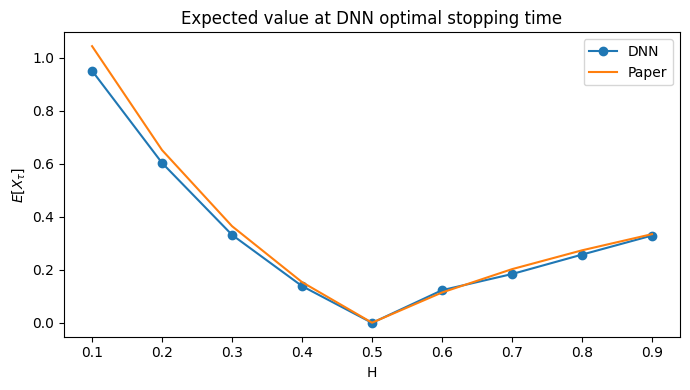

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import iisignature
import matplotlib.pyplot as plt
from fbm import FBM

M = 100
N_TRAIN = 1024
N_TEST  = 1000
N_EPOCHS = 200
LR = 1e-3
SIG_ORDER = 5
dt = 1.0 / M
HURST_VALUES = np.round(np.arange(0.1, 1.0, 0.1), 1)
t_grid = np.linspace(0, 1, M + 1)

LOGSIG_DIM = iisignature.logsiglength(2, SIG_ORDER)
prep = iisignature.prepare(2, SIG_ORDER)

class StoppingNet(nn.Module):
    def __init__(self, d_in, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def compute_logsigs(paths):
    n = len(paths)
    ls = np.zeros((n, M + 1, LOGSIG_DIM), dtype=np.float32)
    for i in range(n):
        for m in range(1, M + 1):
            aug = np.stack([t_grid[:m+1], paths[i, :m+1]], axis=1)
            ls[i, m] = iisignature.logsig(aug, prep)
    return ls

def simulate_paths(n, h):
    out = np.zeros((n, M + 1))
    for i in range(n):
        out[i] = FBM(n=M, hurst=h, length=1, method='daviesharte').fbm()
    return out

def train(model, logsigs_t, Y, n_paths):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for _ in range(N_EPOCHS):
        opt.zero_grad()
        theta = model(logsigs_t[:, 1:].reshape(-1, LOGSIG_DIM)).reshape(n_paths, M)
        I = torch.cumsum(theta ** 2 * dt, dim=1)
        G_prev = torch.cat([torch.ones(n_paths, 1), torch.exp(-I[:, :-1])], dim=1)
        G_curr = torch.exp(-I)
        l = Y[:, M] * G_curr[:, -1] + (Y[:, 1:] * (G_prev - G_curr)).sum(dim=1)
        (-l.mean()).backward()
        opt.step()

@torch.no_grad()
def stopping_times(model, logsigs_t, n_paths):
    theta = model(logsigs_t[:, 1:].reshape(-1, LOGSIG_DIM)).reshape(n_paths, M)
    I = torch.cumsum(theta ** 2 * dt, dim=1).numpy()
    Z = np.random.exponential(1.0, size=n_paths)
    taus = np.full(n_paths, M)
    for i in range(n_paths):
        hit = np.where(I[i] >= Z[i])[0]
        if len(hit): taus[i] = hit[0] + 1
    return taus  # integer step indices

# --- Main loop over H ---
results = {}
for H in HURST_VALUES:
    print(f'H={H:.1f}  training...', end=' ', flush=True)
    model = StoppingNet(LOGSIG_DIM)
    train_paths = simulate_paths(N_TRAIN, H)
    train(model, torch.from_numpy(compute_logsigs(train_paths)),
          torch.tensor(train_paths, dtype=torch.float32), N_TRAIN)
    test_paths = simulate_paths(N_TEST, H)
    taus = stopping_times(model, torch.from_numpy(compute_logsigs(test_paths)), N_TEST)
    x_tau = test_paths[np.arange(N_TEST), taus]  # path value at stopping time
    results[H] = x_tau
    print(f'E[X_tau]={x_tau.mean():.4f}')

# --- Plot ---
Paper_values = [1.043, 0.651, 0.364, 0.153, 0.0, 0.114, 0.202, 0.273, 0.334]

H_vals = list(results.keys())
ev_vals = [results[H].mean() for H in H_vals]
plt.figure(figsize=(7, 4))
plt.plot(H_vals, ev_vals, marker='o', label="DNN")
plt.plot(H_vals, Paper_values, label="Paper")
plt.xlabel('H')
plt.ylabel(r'$E[X_{\tau}]$')
plt.legend()
plt.title('Expected value at DNN optimal stopping time')
plt.tight_layout()
plt.show()
